# Hydromechanical control of plant growth — minimal data reanalysis
**Paper:** V. Laplaud, F. Davy, D. Traynor, P. M. Linstead, J. A. D. Goodfellow, J. Minev, A. L. Walker, O. E. Jensen, J. A. Feenstra, A. T. S. Tay, B. Charrier, O. Hamant, "Assessing the hydromechanical control of plant growth", *J. R. Soc. Interface* **21**(214):20240008 (2024), DOI [10.1098/rsif.2024.0008](https://doi.org/10.1098/rsif.2024.0008).

**Data & code:** Laplaud et al., Zenodo record [10848423](https://zenodo.org/records/10848423) (CC-BY-4.0) — deposited per-gemma fitted area-curve CSVs and the authors' Python analysis scripts.

**Scope (single small demonstration, control condition only):** reanalysis of the *deposited fitted* area-curve data. We recompute (1) growth-onset time $T_s$ and exponential growth rate $G$ for one control experiment (282 gemmae pool across the paper; here the 220531 Ctrl_1+Ctrl_2 pair), (2) elastic modulus $E$, deformation irreversibility and apparent hydraulic conductivity $L_{app}$ from the deposited osmotic-step fits, and (3) the Spearman correlations between growth rate and hydromechanical properties per individual (paper Fig. 5 direction). **We do not** re-run the image segmentation stage, treated (mannitol/ABA) conditions, or full-paper statistics.

**AI-assisted adaptation notice / AI支援に関する明記:** This notebook was AI-assisted; it reuses the authors' deposited fit results and reimplements only small readouts (medians, the Δπ formula from `AreaCurveFitting.py`, Spearman correlations from `StatsFunctions.py`). The authors did not provide this Colab notebook. The executed example and listed checks were validated, but untested behavior is not guaranteed. / 本ノブックはAI支援で作成しました。著者公開のfit済みデータを再解析し、著者コードの数式の一部のみを再実装しています。実行済みの範囲のみ検証済みです。

**日本語の要約:** 本ノブックは、ゼノドーに公開された「個体ごとの面積曲線fit結果CSV」を読み込み、(1) 成長開始時刻 $T_s$ と指数成長率 $G$、(2) 浸透圧ステップからの弾性率 $E$・不可逆変形量・見かけの水伝導度 $L_{app}$、(3) 個体レベルの成長率と水力学的性質のスピアマン相関（論文Fig. 5の方向）を再計算します。

## Runtime selection / ランタイム選択
**Use a CPU runtime** (Runtime → Change runtime type → CPU). This notebook performs tabular reanalysis of ~300 KB CSV files — no GPU or deep-learning framework is needed. Expected end-to-end time: **under 3 minutes**; downloads ≈ 2.4 MB.

**実行環境:** CPU ランタイムを選択してください。GPUは不要です。所要時間は全体で3分未満、ダウンロードは約2.4MBです。

In [ ]:
# Environment: only preinstalled Colab packages are used (no installs needed).
# 開発環境: Colabにプレインストールされたパッケージのみ使用します。
import numpy as np, pandas as pd, scipy, matplotlib, seaborn as sns
import matplotlib.pyplot as plt
import hashlib, urllib.request, json, os

print("Python packages:")
for m in (np, pd, scipy, matplotlib, sns):
    print(f"  {m.__name__} {m.__version__}")

Python packages:
  numpy 2.1.3
  pandas 2.2.3
  scipy 1.16.3
  matplotlib 3.10.0
  seaborn 0.13.2


### Data acquisition / データ取得
We download 4 deposited CSV files from the authors' Zenodo record **10848423** (CC-BY-4.0) via its documented record API: the record JSON is fetched once and each file is verified against **that record's own md5 and size metadata**. Files: control growth curves (`...220531_Ct1/Ct2_AreaFit.csv`) and control osmotic-step curves (`..._Ct1_Osmo/_Ct2_Osmo_AreaFit.csv`) of the same individuals.

ゼノドーのレコードAPIからCSVを4件ダウンロードし、レコードmetadataのmd5・サイズと照合します。

In [ ]:
RECORD = "10848423"  # Zenodo record: 'Data and analysis code for the paper ...', CC-BY-4.0
WANTED = {
    "GlobalData220531_Ct1_AreaFit.csv",      # control growth, chamber 1
    "GlobalData220531_Ct2_AreaFit.csv",      # control growth, chamber 2
    "GlobalData220531_Ct1_Osmo_AreaFit.csv", # osmotic steps, chamber 1
    "GlobalData220531_Ct2_Osmo_AreaFit.csv", # osmotic steps, chamber 2
}

with urllib.request.urlopen(f"https://zenodo.org/api/records/{RECORD}") as r:
    record = json.load(r)
print("Record:", record["metadata"]["title"])
print("License:", record["metadata"]["license"]["id"], "| files in record:", len(record["files"]))

os.makedirs("data", exist_ok=True)
seen = {}
for f in record["files"]:
    if f["key"] in WANTED:
        seen[f["key"]] = f
        dst = os.path.join("data", f["key"])
        if not os.path.exists(dst):
            urllib.request.urlretrieve(f["links"]["self"], dst)
        raw = open(dst, "rb").read()
        got_md5, got_size = hashlib.md5(raw).hexdigest(), len(raw)
        exp_md5 = f["checksum"].split("md5:", 1)[1]
        assert got_md5 == exp_md5 and got_size == f["size"], f"checksum mismatch for {f['key']}"
        print(f"OK  {f['key']}  {got_size} bytes  md5={got_md5}")
assert set(seen) == WANTED, f"missing files: {WANTED - set(seen)}" 

Record: Data and analysis code for the paper 'Assessing the hydromechanical control of plant growth'
License: cc-by-4.0 | files in record: 64
OK  GlobalData220531_Ct2_AreaFit.csv  342299 bytes  md5=a01ca64b30bf98ca7d6ed053c7624328
OK  GlobalData220531_Ct1_AreaFit.csv  425346 bytes  md5=132219bcc837da996446f3a4a634eeb2
OK  GlobalData220531_Ct1_Osmo_AreaFit.csv  318421 bytes  md5=636b88b4c52665160b40d1bfc6b4973d
OK  GlobalData220531_Ct2_Osmo_AreaFit.csv  227942 bytes  md5=c0ca74c3dc4c1f81c3a1bf51b77ffd5b


### Load the deposited fitted data / fit済みデータの読み込み
Each `GlobalData..._AreaFit.csv` holds one row per image frame per gemma (columns `Time (min)`, `Area`, `Img`, …) plus one summary row per gemma (`Img == 0`) with the fit results. We load the files with the gemma name as index — exactly as in the authors' `Paper_DataAndFigs.ipynb` (cell "Growth") — and pool the two control chambers with `pd.concat` (the authors' `DataFrame.append` was removed in pandas 2.x; this is a behavior-preserving adaptation).

CSVは著者のノートブックと同様に `index_col='Ind'` で読み込みます。pandas 2.xで削除された `append` の代わりに `pd.concat` を使用します（挙動は同一）。

In [ ]:
GROWTH_DELAY_MIN = 45  # ExperimentList.py: Delay220531 = 45 min (imbibition -> experiment start)

def load_pool(name_tag_pairs):
    """Load deposited AreaFit CSVs; tag each gemma index with experiment + chamber
    (same tag for the growth and osmotic-step file of a chamber, as the authors do),
    pool with pd.concat (authors' DataFrame.append was removed in pandas 2.x)."""
    dfs = []
    for n, tag in name_tag_pairs:
        df = pd.read_csv(f"data/GlobalData{n}_AreaFit.csv", index_col="Ind")
        df = df.rename(index=lambda s: s + "_" + tag)  # unique per gemma and chamber
        df.loc[:, "Expe"] = tag
        dfs.append(df)
    return pd.concat(dfs)

GD_growth = load_pool([("220531_Ct1", "220531_Ct1"), ("220531_Ct2", "220531_Ct2")])
GD_osmo   = load_pool([("220531_Ct1_Osmo", "220531_Ct1"), ("220531_Ct2_Osmo", "220531_Ct2")])

n_growth = GD_growth.loc[GD_growth["Img"] == 0].shape[0]  # one summary row per gemma
n_osmo   = GD_osmo.loc[GD_osmo["Img"] == 0].shape[0]
print(f"Growth curves : {n_growth} gemmae | Osmotic-step curves : {n_osmo} gemmae")
print("Growth fit columns available:", [c for c in ["tdeb", "Tau", "G", "A0fit", "fitR2", "GR_end"] if c in GD_growth.columns])
print("Osmo fit columns available  :", [c for c in ["Ecomp", "Erel", "E", "L/H_Comp", "RevA", "GR_AfterOC", "fitR2", "fitR2rel"] if c in GD_osmo.columns])

Growth curves : 83 gemmae | Osmotic-step curves : 63 gemmae
Growth fit columns available: ['tdeb', 'Tau', 'G', 'A0fit', 'fitR2', 'GR_end']
Osmo fit columns available  : ['Ecomp', 'Erel', 'E', 'L/H_Comp', 'RevA', 'GR_AfterOC', 'fitR2', 'fitR2rel']


### (1) Growth parameters $T_s$ and $G$ / 成長パラメータ
The authors fit each gemma's area curve with a delayed exponential $A(t)=A_0\exp\!\big((t-T_s)/T\big)$ (`ExpDel` in `AreaCurveFitting.py`) and store $T_s$ (`tdeb`, minutes since imbibition, including the 45 min delay), the time constant `Tau` (min) and $G = 24\cdot 60/\mathrm{Tau}$ (day$^{-1}$) (`AreaCurveFitting.py`, lines ~355-360). We recompute the per-gemma values from the deposited columns and report medians. Paper reference (pooled controls, 282 gemmae): **median $T_s$ = 5.20 h, median $G$ = 0.78 day$^{-1}$** — a plausibility comparison, not a claim of the full 282-gemma pool.

著者は遅延指数関数で各個体の面積曲線をfitしています。ここでは保存されたfit結果から $T_s$ と $G$ を抽出し中央値を報告します。

In [ ]:
sum_rows = GD_growth.loc[GD_growth["Img"] == 0].copy()
growth = pd.DataFrame({
    "Ts_h":  sum_rows["tdeb"] / 60.0,        # tdeb is in minutes (incl. 45 min delay)
    "G_d-1": sum_rows["G"],                   # deposited as 24*60/Tau
    "Tau_min": sum_rows["Tau"],
    "fitR2": sum_rows["fitR2"],
})
summary = growth.agg(["median", "mean"]).round(3)
summary.index = ["median", "mean"]
print(summary)
print()
print(f"Median Ts = {growth['Ts_h'].median():.2f} h   (paper, pooled controls: 5.20 h)")
print(f"Median G  = {growth['G_d-1'].median():.2f} day^-1 (paper, pooled controls: 0.78 day^-1)")
growth.to_csv("growth_parameters_220531_Ctrl.csv", index=False)

         Ts_h  G_d-1   Tau_min  fitR2
median  5.253  0.818  1761.383  0.997
mean    5.303  0.779  1965.932  0.996

Median Ts = 5.25 h   (paper, pooled controls: 5.20 h)
Median G  = 0.82 day^-1 (paper, pooled controls: 0.78 day^-1)


### Raw area curves with the deposited delayed-exponential fit / 生の面積曲線とfit曲線
Each deposited row carries the raw measured area (`Area`, mm²) per frame. We overlay the deposited fit parameters ($A_0$ = `A0fit`, `Tau`, `tdeb`) reconstructed with the authors' `ExpDel.f()` form, $A(t)=A_0$ for $t<T_s$ and $A_0\exp((t-T_s)/T)$ afterwards. `Time (min)` starts at experiment start, while `tdeb` counts from imbibition, so the deposited $T_s$ is shifted back by the 45 min delay (`Delay220531`) for overlay — a plot alignment only, not a refit.

各個体の生の面積曲線に、保存されたfitパラメータから再構成した遅延指数関数を重ねて描きます。

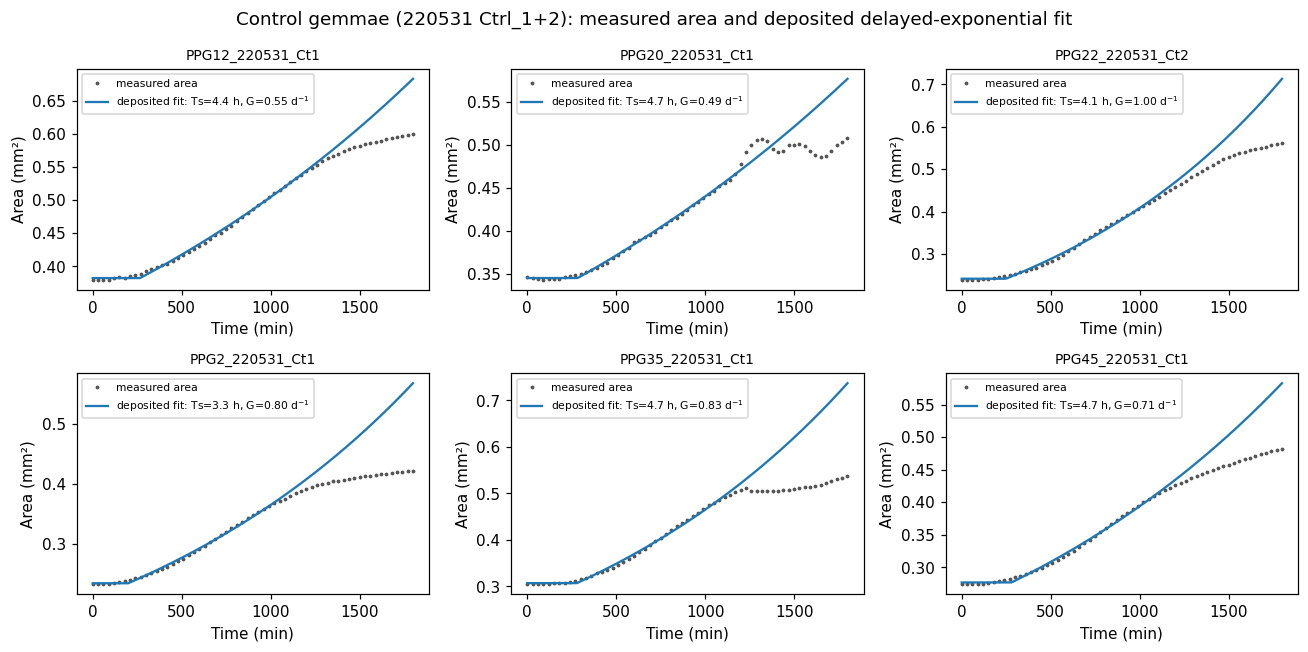

In [ ]:
rng = np.random.default_rng(0)  # deterministic example selection
sample_gemmae = rng.choice(np.unique(GD_growth.index), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=110, sharex=False)
for ax, g in zip(axes.ravel(), sorted(sample_gemmae)):
    sub = GD_growth.loc[g].drop_duplicates(subset="Img")
    t = sub["Time (min)"].values.astype(float)
    a = sub["Area"].values.astype(float)
    r = sub.iloc[0]
    ts = r["tdeb"] - GROWTH_DELAY_MIN  # shift deposited Ts back into frame time
    tfit = np.linspace(t.min(), t.max(), 200)
    afit = np.where(tfit < ts, r["A0fit"], r["A0fit"] * np.exp((tfit - ts) / r["Tau"]))
    ax.plot(t, a, ".", ms=3, color="#555", label="measured area")
    ax.plot(tfit, afit, "-", lw=1.5, color="#1f77b4",
            label=f"deposited fit: Ts={ts/60:.1f} h, G={r['G']:.2f} d$^{{-1}}$")
    ax.set_title(g, fontsize=9)
    ax.set_xlabel("Time (min)"); ax.set_ylabel("Area (mm²)")
    ax.legend(fontsize=7)
fig.suptitle("Control gemmae (220531 Ctrl_1+2): measured area and deposited delayed-exponential fit")
fig.tight_layout()
plt.show()

### (2) Osmotic-step hydromechanics / 浸透圧ステップによる水力学特性
From the +100 mM mannitol osmotic steps, the authors fit compression and relaxation with an exponential-plus-linear model (`fitFuncOsmChoc2`, `AreaCurveFitting.py:394`) and compute, with the osmotic pressure step $\Delta\pi = R\,T\,C = 8.314 \times 298\,\mathrm{K} \times 100\,\mathrm{mol\,m^{-3}}/10^6 = 0.2478$ MPa:
- elastic modulus $E$ (deposited columns `Ecomp`, `Erel`, `E = (Ecomp+Erel)/2`, MPa),
- deformation irreversibility `RevA` = $|\Delta A_{rel}/\Delta A_{comp}|$,
- apparent conductivity over thickness `L/H_Comp` = $1/(\tau \cdot 60 \cdot E)$ m s$^{-1}$ Pa$^{-1}$ (the paper's $L_{app}$ up to the unknown gemma thickness $H$),
- post-shock growth rate `GR_AfterOC` (day$^{-1}$, the paper's $G_{post}$).

We report the per-gemma distribution from the deposited fits.

浸透圧ステップのfit結果から $E$、不可逆性、$L_{app}$、$G_{post}$ の分布を集計します。

In [ ]:
DELTA_PI_MPA = 8.314 * 298 * 100 / 1e6  # MPa, AreaCurveFitting.py (R * 298 K * 100 mol/m3)
print(f"Osmotic pressure step Δπ = {DELTA_PI_MPA:.4f} MPa")

osum = GD_osmo.loc[GD_osmo["Img"] == 0].copy()
hydro = osum[["Ecomp", "Erel", "E", "L/H_Comp", "RevA", "GR_AfterOC", "fitR2", "fitR2rel"]].copy()
print(hydro.agg(["median"]).round(4))
print()
print(f"Median E (mean of comp & rel)      = {hydro['E'].median():.3f} MPa")
print(f"Median irreversibility RevA        = {hydro['RevA'].median():.3f}")
print(f"Median L_app = L/H (compression)   = {hydro['L/H_Comp'].median():.3e} m s^-1 Pa^-1")
print(f"Median G_post (GR_AfterOC)         = {hydro['GR_AfterOC'].median():.2f} day^-1")
hydro.to_csv("hydromechanical_properties_220531_Ctrl.csv", index=False)

Osmotic pressure step Δπ = 0.2478 MPa
          Ecomp     Erel        E  L/H_Comp    RevA  GR_AfterOC  fitR2  \
median  16.6372  15.1413  16.2121       0.0  1.0733      0.3434  0.988   

        fitR2rel  
median     0.995  

Median E (mean of comp & rel)      = 16.212 MPa
Median irreversibility RevA        = 1.073
Median L_app = L/H (compression)   = 1.256e-09 m s^-1 Pa^-1
Median G_post (GR_AfterOC)         = 0.34 day^-1


#### Distributions of $E$, $L_{app}$ and irreversibility / 分布の可視化
Additional visualization created for this notebook (not an author figure): per-gemma distributions of the deposited hydromechanical readouts for the control osmotic-step experiment. / 論文図ではなく本ノブック用の追加可視化です。

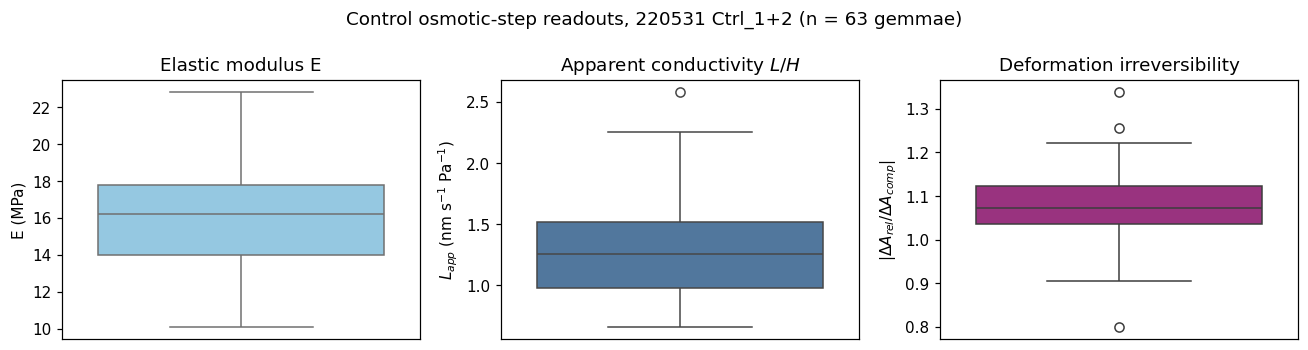

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), dpi=110)
sns.boxplot(y=hydro["E"], ax=axes[0], color="#88ccee")
axes[0].set_ylabel("E (MPa)"); axes[0].set_title("Elastic modulus E")
sns.boxplot(y=hydro["L/H_Comp"] * 1e9, ax=axes[1], color="#4477aa")
axes[1].set_ylabel(r"$L_{app}$ (nm s$^{-1}$ Pa$^{-1}$)"); axes[1].set_title(r"Apparent conductivity $L/H$")
sns.boxplot(y=hydro["RevA"], ax=axes[2], color="#aa2288")
axes[2].set_ylabel(r"$|\Delta A_{rel}/\Delta A_{comp}|$"); axes[2].set_title("Deformation irreversibility")
for ax in axes:
    ax.set_xticks([])
fig.suptitle("Control osmotic-step readouts, 220531 Ctrl_1+2 (n = %d gemmae)" % len(hydro))
fig.tight_layout()
plt.show()

### (3) Per-individual growth–hydromechanics correlations / 成長率と水力学的性質の相関
The paper's Fig. 5 links growth rate with $E$ and $L_{app}$ measured on the same gemmae. In `Paper_DataAndFigs.ipynb` (`GOC_Comp` call, cell "Mechanics → Controls") the paper pairs, via Spearman correlations (as in `StatsFunctions.Corr`), the growth-table quantities `G` (deposited exponential rate) and `GR_end` (mean relative growth rate near the end of the growth recording — the paper's $G_{inst}$) with the osmotic-step quantities `GR_AfterOC` (the paper's $G_{post}$) and `Ecomp`. Gemma names are shared between the growth and osmotic-step tables of the same chambers, so we join on the unique gemma index and compute the same pairings — for one control experiment here, versus the paper's 179 pooled control gemmae (report: $G_{inst}$ vs $E$ $\rho=-0.503$, $p<10^{-10}$; vs $L_{app}$ positive).

成長テーブル（`G`、`GR_end`）と浸透圧テーブル（`Ecomp`、`L/H_Comp`、`GR_AfterOC`）を個体名で結合し、論文と同じ組合せでスピアマン相関を計算します。

In [ ]:
# Growth-table readouts (same gemmae were measured for growth and osmotic steps)
g_read = sum_rows[["G", "GR_end"]]
h_read = osum[["Ecomp", "L/H_Comp", "GR_AfterOC"]]
g_idx = g_read.join(h_read, how="inner")  # join on unique gemma name
print(f"Matched gemmae between growth and osmotic-step tables: {len(g_idx)}")

pairs = [("GR_end", "Ecomp"), ("GR_end", "L/H_Comp"), ("G", "GR_AfterOC")]
labels = [("G_inst", "E"), ("G_inst", "L_app"), ("G", "G_post")]
for (x, y), (xl, yl) in zip(pairs, labels):
    rho, p = scipy.stats.spearmanr(g_idx[x], g_idx[y], nan_policy="omit")
    print(f"Spearman {xl} vs {yl} : rho = {rho:.3f}, p = {p:.2e}  (n = {g_idx[[x, y]].dropna().shape[0]})")
print("Paper Fig 5 (179 pooled control gemmae): G_inst vs E rho = -0.503; vs L_app rho > 0")
g_idx.to_csv("growth_vs_hydromechanics_220531_Ctrl.csv", index=False)

Matched gemmae between growth and osmotic-step tables: 55
Spearman G_inst vs E : rho = -0.498, p = 1.10e-04  (n = 55)
Spearman G_inst vs L_app : rho = 0.321, p = 1.69e-02  (n = 55)
Spearman G vs G_post : rho = -0.225, p = 9.79e-02  (n = 55)
Paper Fig 5 (179 pooled control gemmae): G_inst vs E rho = -0.503; vs L_app rho > 0


#### Scatter views / 散布図
Additional visualization created for this notebook (not an author figure). / 本ノブック用の追加可視化です。

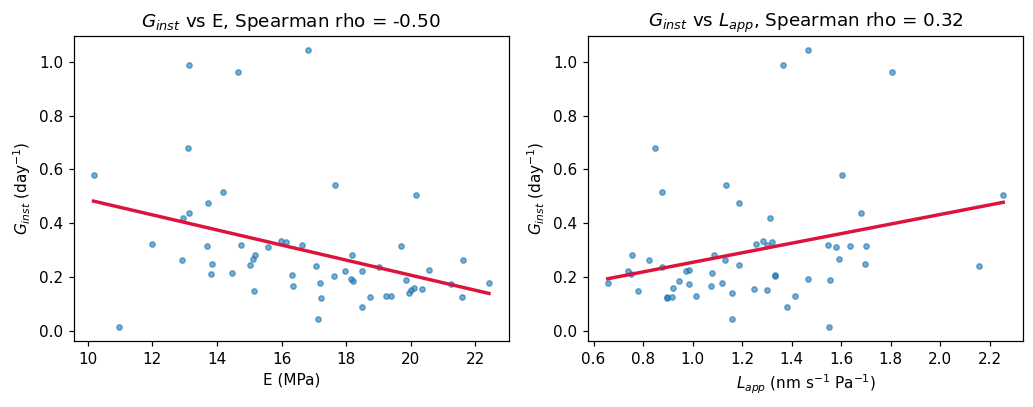

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), dpi=110)
sns.regplot(x=g_idx["Ecomp"], y=g_idx["GR_end"], ax=axes[0], ci=None,
            scatter_kws={"s": 12, "alpha": 0.6}, line_kws={"color": "crimson"})
axes[0].set_xlabel("E (MPa)"); axes[0].set_ylabel(r"$G_{inst}$ (day$^{-1}$)")
rho_E, _ = scipy.stats.spearmanr(g_idx["GR_end"], g_idx["Ecomp"], nan_policy="omit")
axes[0].set_title(f"$G_{{inst}}$ vs E, Spearman rho = {rho_E:.2f}")
sns.regplot(x=g_idx["L/H_Comp"] * 1e9, y=g_idx["GR_end"], ax=axes[1], ci=None,
            scatter_kws={"s": 12, "alpha": 0.6}, line_kws={"color": "crimson"})
axes[1].set_xlabel(r"$L_{app}$ (nm s$^{-1}$ Pa$^{-1}$)"); axes[1].set_ylabel(r"$G_{inst}$ (day$^{-1}$)")
rho_L, _ = scipy.stats.spearmanr(g_idx["GR_end"], g_idx["L/H_Comp"], nan_policy="omit")
axes[1].set_title(f"$G_{{inst}}$ vs $L_{{app}}$, Spearman rho = {rho_L:.2f}")
fig.tight_layout()
plt.show()

## Interpretation and limitations / 解釈と限界
- **What was executed:** reanalysis of the authors' deposited, already-fitted area-curve data for one control experiment (220531 Ctrl_1+2): growth parameters ($T_s$, $G$), osmotic-step hydromechanics ($E$, irreversibility, $L_{app} = L/H$, $G_{post}$), and per-individual Spearman correlations.
- **Expected relation to the paper:** the deposited control medians ($T_s$ ≈ 5 h, $G$ ≈ 0.8 day$^{-1}$) and the correlation signs (growth rate negatively correlated with $E$, positively with $L_{app}$) should match the paper's pooled-control and Fig. 5 findings. Small numeric differences versus the printed paper values are expected because this notebook uses one experiment while the paper pools four (282 gemmae).
- **Not reproduced (scope omissions / 未実行の範囲):** image segmentation (`GemmaeDetection.py` — no raw image stacks are deposited), curve fitting from raw areas, mannitol and ABA conditions, two-way ANOVA and pooled statistics, and the model derivation. Gemma thickness $H$ is not measured per individual, so only $L_{app} = L/H$ is available, as the authors themselves note.
- **Provenance:** all numbers come from Zenodo record 10848423 files with md5 verification; formulas follow `AreaCurveFitting.py` and `StatsFunctions.py` of the same record. License: CC-BY-4.0 — cite the paper and the dataset when reusing.

**参考文献:** Laplaud et al. 2024 (DOI 10.1098/rsif.2024.0008); Zenodo record 10848423 (CC-BY-4.0).